#### Data

In [59]:
import numpy as np
import pandas as pd
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

#### Generate Data

In [60]:



def generate_data(n=10):
    # Red
    r_red = np.random.randint(150, 256, n)
    g_red = np.random.randint(0, 51, n)
    b_red = np.random.randint(0, 51, n)
    
    X_red = np.column_stack((r_red, g_red, b_red))
    y_red = -1 * np.ones(n) 

    # Blue
    r_blue = np.random.randint(0, 51, n)
    g_blue = np.random.randint(0, 51, n)
    b_blue = np.random.randint(150, 256, n)
    
    X_blue = np.column_stack((r_blue, g_blue, b_blue))
    y_blue = np.ones(n)   

    # Combine
    X = np.vstack((X_red, X_blue))
    y = np.hstack((y_red, y_blue))
    
    # Shuffle
    X, y = shuffle(X, y, random_state=42)
    
    return X, y


#### Activation function

In [61]:
def sign_func(z):
    return 1 if z >= 0 else -1

#### Perceptron Algo

In [62]:
def perceptron(X, y, lr, epochs):
    m, n = X.shape
    
    w = np.zeros((n + 1, 1))
    errors = []
    
    for epoch in range(epochs):
        n_miss = 0
        for idx, x_i in enumerate(X):
            x_i_bias = np.insert(x_i, 0, 1).reshape(-1, 1)
            
         
            z = np.dot(w.T, x_i_bias)
            
           
            y_hat = sign_func(z)
            
          
            if y_hat != y[idx]:
                # Update
                error = y[idx] - y_hat
                w += lr * error * x_i_bias
                n_miss += 1
                
        errors.append(n_miss)
        
        if n_miss == 0:
            break
            
    return w, errors

#### Implementation

In [63]:
# Generate
X_rgb, y_rgb = generate_data(n=100)

# Verify
df = pd.DataFrame(X_rgb[:5], columns=['Red', 'Green', 'Blue'])
df['Label'] = y_rgb[:5]
print("Sample Data:")
display(df)

Sample Data:


,Red,Green,Blue,Label
0,153,50,37,-1.0
1,165,27,43,-1.0
2,213,36,32,-1.0
3,6,8,236,1.0
4,33,26,229,1.0


In [64]:

LR = 0.01
EPOCHS = 5

# Train
w_final, error_history = perceptron(X_rgb, y_rgb, LR, EPOCHS)

print(f"Weights:\n{w_final.flatten()}")
print(f"Errors per Epoch: {error_history}")


Weights:
[ 0.   -2.94 -0.84  3.98]
Errors per Epoch: [2, 0]


#### Boundry

##### w0 + w1*x + w2*y + w3*z = 0 

##### ==> z = -(w1*x + w2*y + w0) / w3

In [65]:


def plot_3d_boundary(X, y, w):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot Data
    ax.scatter(X[y == -1][:, 0], X[y == -1][:, 1], X[y == -1][:, 2], 
               c='red', marker='^', label='Class -1 (Red Dominant)')
    

    ax.scatter(X[y == 1][:, 0], X[y == 1][:, 1], X[y == 1][:, 2], 
               c='blue', marker='s', label='Class 1 (Blue Dominant)')

    # Decision Boundary
    if w[3] != 0:
        x_min, x_max = X[:, 0].min(), X[:, 0].max()
        y_min, y_max = X[:, 1].min(), X[:, 1].max()
        
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 10),
                             np.linspace(y_min, y_max, 10))
        
        z = -(w[1] * xx + w[2] * yy + w[0]) / w[3]
        
        # Plot
        ax.plot_surface(xx, yy, z, alpha=0.3, color='green')
        
    ax.set_xlabel('Red ($x_1$)')
    ax.set_ylabel('Green ($x_2$)')
    ax.set_zlabel('Blue ($x_3$)')
    ax.set_title('RGB Classification with Perceptron Plane')
    ax.legend()
    
    plt.show()



#### Training

Weights:
[ 0.   -2.94 -0.84  3.98]
Errors per Epoch: [2, 0]


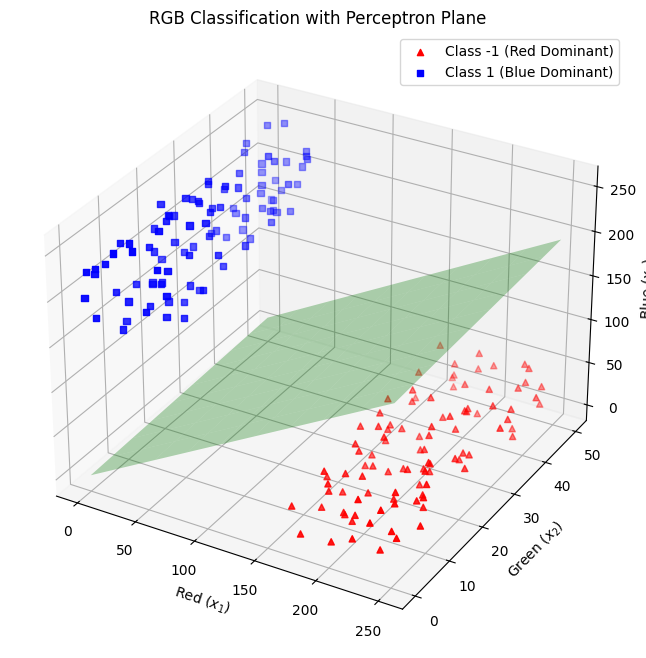

In [66]:
LR = 0.01
EPOCHS = 5

# Train
w_final, error_history = perceptron(X_rgb, y_rgb, LR, EPOCHS)

print(f"Weights:\n{w_final.flatten()}")
print(f"Errors per Epoch: {error_history}")

#visualize
plot_3d_boundary(X_rgb, y_rgb, w_final)

#### Testing

Test Accuracy:     100.0%


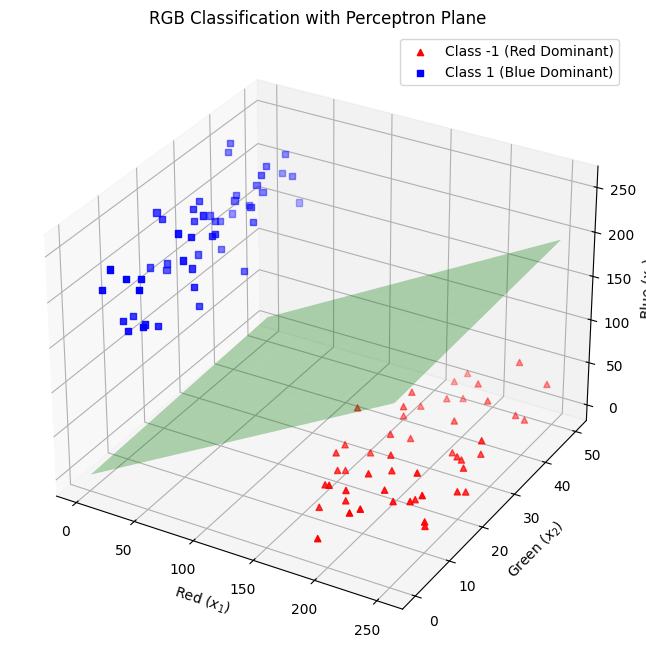

In [67]:
#test data
X_test, y_test = generate_data(n=50) 

# Evaluate
correct_test = 0
for i in range(len(X_test)):
    x_sample = np.insert(X_test[i], 0, 1).reshape(-1, 1)
    prediction = sign_func(np.dot(w_final.T, x_sample))
    if prediction == y_test[i]:
        correct_test += 1
print(f"Test Accuracy:     {(correct_test / len(X_test)) * 100}%")
plot_3d_boundary(X_test, y_test, w_final)